# Machine Learning Foundations – Assignment 1  
## Logistic Regression on Bank Marketing Dataset  

**Author:** Rishi Gupta  
**GitHub Repository:** https://github.com/RISHI-ai-maker/ML-fundamentals-2026


In [2]:
import pandas as pd

df = pd.read_csv("bank-additional.csv", sep=";")
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


# 1. Identifying the Prediction Target

**Goal**: determine whether the client will subscribe to a term deposit after we contact the client.

**Prediction target**: the variable y, which indicates the client’s subscription status.

y takes the following values:
- yes: the client subscribed
- no: the client did not subscribe

This aligns with the real-world objective because we want to make a prediction at the time of contact.

In [3]:
df.columns 

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [4]:
df["y"].value_counts()
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

# Interpretation

The data is heavily skewed, with 89% of the data points being negative and 11% of the data points being positive. This is an important point to consider as we go about modeling the data.

If we were to build a naive classifier, one that always guesses the majority class, we could expect to get 89% accuracy. However, such a classifier would be useless to us, as it would fail to identify all potential subscribers, i.e., the minority class. Therefore, accuracy is not an appropriate measure in this case.

# 2. Data Loading and Exploration

Before we move on to the preprocessing step, we should look at the structure of the dataset and the features. We should look at the number of entries, the types of the entries, the summary statistics, etc. We should also look at the numeric variables and the categorical variables.

Exploring the data a little at this stage allows us to identify issues like missing values, extreme values, unusual coding schemes, etc.

In [5]:
df.shape

(4119, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

categorical_cols, numerical_cols

(Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome', 'y'],
       dtype='object'),
 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'))

In [9]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [10]:
for col in categorical_cols:
    if "unknown" in df[col].unique():
        print(col)

job
marital
education
default
housing
loan


# Interpretation
The data contains 4,119 data points and 21 variables. There are no explicit NaN values in the data, although some categorical variables use the term 'unknown' as an indicator of implicit missing data.

There are numerical and categorical variables. However, the Logistic Regression model can only work with numerical data. So, the categorical data must be encoded.

The variable 'duration' is varying greatly and shows the length of the call. This data is only available after the call has ended. So, if the model is being used during the call, it is an instance of data leakage.

# 3. Data Splitting

The data set is then split into training, validation, and test sets, with the proportions ***70%, 15%, and 15%,*** respectively, using stratified sampling. This ensures that the imbalance present in the original data set remains the same for all the subsets.

 Most importantly, the splitting occurs before any preprocessing. This ensures that there is no information leakage from the validation or test sets into the scaling, encoding, or imputation processes. 


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"]

# First split: Train (70%) and Temporary (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (2883, 20)
Validation shape: (618, 20)
Test shape: (618, 20)


In [12]:
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

Validation distribution:
 y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64

Test distribution:
 y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64


# Interpretation

The dataset has been successfully divided into training, validation, and test sets. The sizes of each set are as follows:

- Training set: 2,883 observations
- Validation set: 618 observations
- Test set: 618 observations
  
Stratified sampling is used to ensure that the class distribution of the data is preserved across all sets. The ratio of the positive class, i.e., "yes," is still close to 11 percent in each set. This shows that stratified sampling has been properly applied.
This is an important step, especially given the class imbalance in the data. Without stratified sampling, one of the sets, i.e., either the validation set or the test set, could have very few data points belonging to the positive class. This would lead to incorrect evaluation metrics.
It is crucial to note that the dataset is divided before any of the preprocessing steps. This is to ensure that all the preprocessing steps, i.e., imputation, encoding, scaling, feature selection, and sampling, are carried out only on the training set. If the preprocessing steps were carried out before the dataset was divided, it would lead to data leakage, and hence, the model would be evaluated incorrectly.

# 4. Managing Missing Values

Even though we do not have any null values, we do have some categorical variables that contain ***“unknown”*** values, which we consider to be a special case of missing values.

Another column, pdays, contains a special value of ***999*** to denote clients who were not contacted previously.

In [13]:
# Recompute column lists from X_train 
categorical_cols = X_train.select_dtypes(include="object").columns
numerical_cols = X_train.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [14]:
for col in categorical_cols:   #checking unkown columns
    if "unknown" in X_train[col].unique():
        print(col)

job
marital
education
default
housing
loan


In [15]:
import numpy as np               #Handle pdays = 999

for X_ in (X_train, X_val, X_test):
    X_["previous_contact"] = (X_["pdays"] != 999).astype(int)
    X_.loc[X_["pdays"] == 999, "pdays"] = np.nan

In [16]:
X_train[["pdays", "previous_contact"]].head()
X_train["pdays"].isna().mean()

np.float64(0.9587235518557059)

# Interpretation 

Implicit missing values were retained as separate categories rather than removed. In many cases, missingness itself can carry predictive information.

For `pdays`, a new binary feature `previous_contact` was created to explicitly capture whether a client had been contacted before. The sentinel value `999` was replaced with `NaN` to allow appropriate imputation.

This approach separates meaningful information (previous contact status) from artificial numeric coding, improving model interpretability and preventing distortion during scaling.


# 5. Encoding Categorical Variables


We have handled categorical variables by performing ***One-Hot Encoding***. One-Hot Encoding is a technique that allows Logistic Regression to learn different coefficients for different levels in categorical variables without assuming any order or priority.

We have trained the One-Hot Encoder model on the training data and then applied it to the validation and test data, which maintains the consistency in the feature space.


In [17]:
for X_ in (X_train, X_val, X_test):    #remove duration because it is not available at prediction time.
    X_.drop(columns=["duration"], inplace=True) 

In [18]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

In [19]:
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [20]:
print("Train shape:", X_train_encoded.shape)
print("Validation shape:", X_val_encoded.shape)
print("Test shape:", X_test_encoded.shape)

Train shape: (2883, 53)
Validation shape: (618, 53)
Test shape: (618, 53)


# Interpretation
After performing One-Hot Encoding, the feature space now has 53 variables. This allows the model to detect category-specific effects, but it also makes it slightly more complex.

One-Hot Encoding is a good technique for linear models because it ensures that we do not introduce any artificial order or relationship between the variables. The consistency in the column order and data alignment for all the datasets ensures that we do not have evaluation inconsistencies.

# 6. Feature Scaling

In this step, we standardized the numerical variables, and now each variable has a standard deviation of 1 and a mean of 0.

This is a very important step for Logistic Regression, as it uses a gradient-based optimization technique.


In [21]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Make copies 
X_train_scaled = X_train_encoded.copy()
X_val_scaled = X_val_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Identify numeric columns
numeric_cols = X_train_scaled.select_dtypes(include=["int64", "float64"]).columns

# Fit only on training data
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])

# Apply same transformation to validation and test
X_val_scaled[numeric_cols] = scaler.transform(X_val_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

In [22]:
X_train_scaled[numeric_cols].describe().loc[["mean", "std"]]

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previous_contact
mean,-4.929190e-18,-7.393785e-18,6.717316e-17,1.016645e-17,-4.682730e-17,-2.980928e-15,6.629761e-16,-4.436271e-17,1.025456e-14,5.175649e-17
std,1.000173e+00,1.000173e+00,1.004228e+00,1.000173e+00,1.000173e+00,1.000173e+00,1.000173e+00,1.000173e+00,1.000173e+00,1.000173e+00


# Interpretation

After applying the feature scaling, the numerical variables are now centered around 0 in terms of the mean and are close to 1 in terms of the standard deviation, indicating a successful standardization of the variables.

# 7. Feature Selection

 linear models like Logistic Regression, there are two major pitfalls that we should always watch out for:

- ***Features with low variance:*** Features that don’t vary much don’t help us differentiate between outcomes.
- ***Multicollinearity:*** If two or more features are correlated with each other, this can cause problems.

The selection of which features to retain needs to be based solely on the training data and not on the validation or test data results, as this would lead to data leakage.

In [23]:
X_train_scaled.var().sort_values().head(10)

default_yes             0.000347
education_illiterate    0.000347
marital_unknown         0.002423
month_dec               0.005864
job_unknown             0.008599
month_mar               0.010641
month_sep               0.015706
month_oct               0.018052
job_student             0.018052
housing_unknown         0.022045
dtype: float64

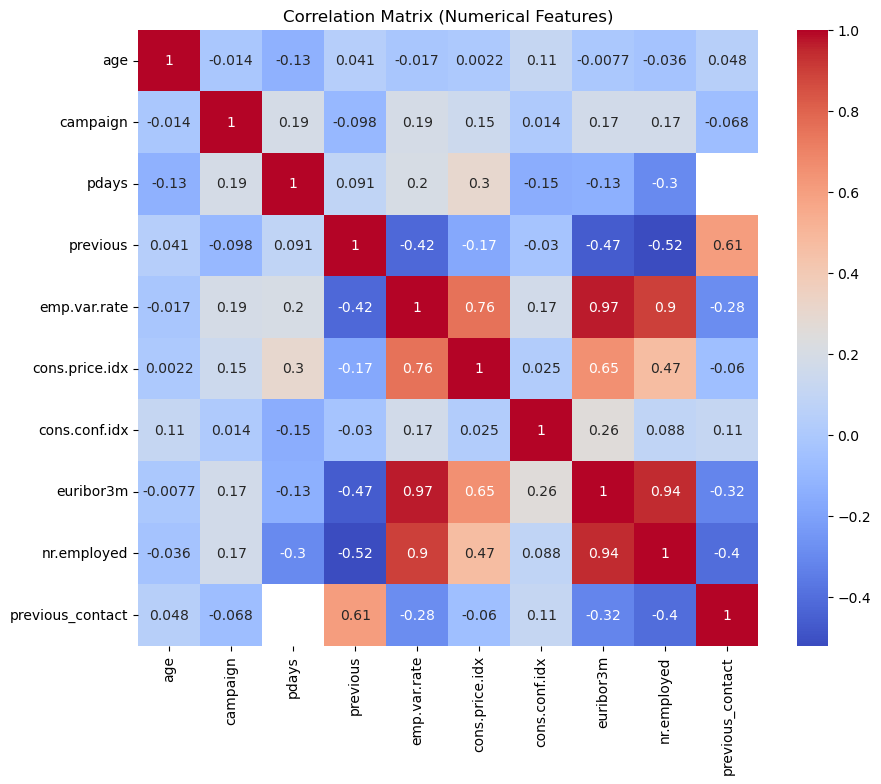

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(X_train_scaled[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

# Interpretation

The analysis of variance indicated that only a few features changed by almost zero in the training data. Features with nearly zero variance do not contribute any useful information for classification and are pruned.

In the correlation analysis, strong multicollinearity was found among some of the macroeconomic variables, particularly emp.var.rate, euribor3m, and nr.employed. These variables are essentially telling the same economic story. Including all these variables would make the model’s coefficients unstable if the model is linear.

In order to make the model sturdier and easier to interpret, redundant features are pruned while retaining one of the macroeconomic variables.

Most importantly, the feature selection is based only on the training data in order to adhere strictly to methodological discipline.

# 8. Addressing Class Imbalance

The target variable has a strong class imbalance, indicating ***11%*** of the data falls in the positive class.

Class imbalance in the target variable may influence classification models, resulting in high accuracy for the class with the majority of the data.

To avoid class imbalance, the training data set will be subjected to the ***Synthetic Minority Oversampling Technique, or simply SMOTE***.

In this technique, synthetic data points are created for the minority class by interpolating points in the feature space.

Note that only the training data set is being resampled, and the validation and test data sets retain their original class distribution to ensure unbiased evaluation of the model.

In [25]:
from sklearn.impute import SimpleImputer 

imputer = SimpleImputer(strategy="median")

# Fit on training set only
X_train_imputed = X_train_scaled.copy()
X_val_imputed = X_val_scaled.copy()
X_test_imputed = X_test_scaled.copy()

X_train_imputed[numeric_cols] = imputer.fit_transform(X_train_scaled[numeric_cols])
X_val_imputed[numeric_cols] = imputer.transform(X_val_scaled[numeric_cols])
X_test_imputed[numeric_cols] = imputer.transform(X_test_scaled[numeric_cols])

In [26]:
from imblearn.over_sampling import SMOTE

y_train_binary = y_train.map({"no": 0, "yes": 1})

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_imputed,
    y_train_binary
)

print("Before SMOTE:\n", y_train_binary.value_counts(normalize=True))
print("\nAfter SMOTE:\n", pd.Series(y_train_balanced).value_counts(normalize=True))

Before SMOTE:
 y
0    0.890392
1    0.109608
Name: proportion, dtype: float64

After SMOTE:
 y
0    0.5
1    0.5
Name: proportion, dtype: float64


# Interpretation
The training dataset, after the application of SMOTE, shows a perfect balance of 50/50 between the positive and negative classes. This is to ensure that the model does not become biased towards the majority class.

The validation dataset and the test dataset were left unchanged. It is essential to leave the datasets unchanged to ensure that the evaluation process follows the same principles as the actual deployment process.

The application of SMOTE to the dataset before splitting would have resulted in a data leakage problem.

# 9. Training Logistic Regression

We have created a Logistic Regression model, and it has been trained on the balanced set of data.

Logistic Regression is a linear classifier, and it uses the logistic function to estimate probabilities of classes to which data points belong.

Evaluation
Evaluation of the model has been done on the validation set, in which the class imbalance has been preserved.


In [27]:
from sklearn.linear_model import LogisticRegression


log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train on balanced data
log_reg.fit(X_train_balanced, y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [28]:
y_val_binary = y_val.map({"no": 0, "yes": 1})

y_val_pred = log_reg.predict(X_val_imputed)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(y_val_binary, y_val_pred)
precision = precision_score(y_val_binary, y_val_pred)
recall = recall_score(y_val_binary, y_val_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_binary, y_val_pred))

Accuracy: 0.8559870550161812
Precision: 0.352112676056338
Recall: 0.36764705882352944

Confusion Matrix:
[[504  46]
 [ 43  25]]


In [30]:
import numpy as np  #Compare to Zero Rule Baseline

zero_rule_accuracy = np.mean(y_val_binary == 0)
print("Zero Rule Accuracy:", zero_rule_accuracy)

Zero Rule Accuracy: 0.889967637540453


# Interpretation

The accuracy of the model is somewhat lower than the baseline accuracy of the Zero Rule algorithm. This is reasonable because the Zero Rule algorithm is based on the idea of choosing the majority class and discarding the minority classes.

The model has non-zero recall for the positive class. This is important because the Zero Rule algorithm has zero recall for the subscribers class. The model is able to classify the positive class correctly.

Precision is also non-zero. This means the model is not perfect. However, in the context of marketing, it is often more important to find potential subscribers than to minimize false positives.

# 10.  Task Ordering and Methodological Justification

The preprocessing and modeling steps followed in this notebook have been performed with a certain order to ensure methodological integrity and prevent data leakage. The order of operations is not random in supervised machine learning models because certain operations, if performed incorrectly, may lead to biased performance estimates and overly optimistic results.

***The workflow followed this sequence:***

***1. Identification of the prediction target  
2. Splitting the dataset into training, validation, and test sets  
3. Handling implicit and explicit missing values  
4. Encoding categorical variables  
5. Scaling numerical features  
6. Feature selection  
7. Addressing class imbalance using SMOTE  
8. Training and evaluating the Logistic Regression model***

This division was performed immediately after the target for prediction was identified. This is a critical phase of the entire data science pipeline. Any operations that require parameters to be estimated from the data must be performed on the training data only. This includes operations such as imputation of missing data, encoding of data, scaling of data, feature selection, or resampling of data. The reason for this is that if any of these operations are performed on the entire data or on the validation or test data prior to division, data leakage will occur.

Missing data handling was performed after division of the data. Therefore, statistics obtained during this phase are based on the training data only.

Encoding of data was performed on the training data only and was applied to all data for consistency.

Scaling of data was performed after encoding of data because scaling is performed on numerical data only.

Feature selection was performed based on the data obtained from the training data only. If feature selection is performed based on the validation data, selection bias will enter into the evaluation.

For handling class imbalance, SMOTE was applied to the data. However, this was performed on the data obtained from the training data only.

Finally, a Logistic Regression model was trained on the data obtained from the balanced data and evaluated on the validation data.

In summary, the entire data science pipeline was performed in a way that ensures integrity is maintained, data leakage is avoided, and evaluation is performed on data that realistically estimates the performance of the machine learning model.
